# Read the economic exposure map

A sector name is not a factor portfolio. Compare market, size, value, profitability, investment and momentum sensitivities in their original units, then separate fitted contributions from residual risk.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Question
What does a technology or utilities label tell us about the fund's economic risks? The primary panel uses 9 original State Street Select Sector SPDR funds over January 2007–July 2026. A separate, shorter panel includes all eleven current sectors. Full-sample estimates describe their stated samples; they do not reconstruct historical holdings or backcast today's sector definitions.

In [2]:
from research.data import FACTORS, SECTORS, load_panel
from research.models import fit_factor_model, hac_ols
x, y, audit = load_panel()
exposures = pd.read_csv(RESULTS / 'exposures.csv').drop(columns='ticker').set_index('sector')
display(exposures.round(3))

,Mkt-RF,SMB,HML,RMW,CMA,Mom,r_squared,residual_vol_annual_pct
sector,,,,,,,,
Consumer Discretionary,1.062,0.192,-0.147,0.133,-0.167,-0.102,0.855,7.448
Consumer Staples,0.667,-0.207,-0.047,0.419,0.532,0.048,0.653,7.326
Energy,1.005,0.276,0.557,0.417,0.465,0.009,0.532,18.185
Financials,1.047,-0.193,0.850,-0.251,-0.310,-0.179,0.887,7.519
Health Care,0.728,-0.065,-0.139,0.022,0.392,0.028,0.574,9.356
Industrials,1.083,0.134,0.176,0.147,0.170,-0.010,0.870,6.914
Materials,1.082,0.105,0.109,0.256,0.270,-0.076,0.778,9.582
Technology,1.145,-0.275,-0.262,-0.147,-0.154,0.039,0.859,7.281
Utilities,0.582,-0.151,-0.059,0.315,0.385,0.176,0.321,12.175


## Compare the factor sensitivities
Beta 1 means a one-percentage-point factor return contributes one percentage point to the fitted ETF excess return, conditional on the other factors. A coefficient is not a portfolio weight.

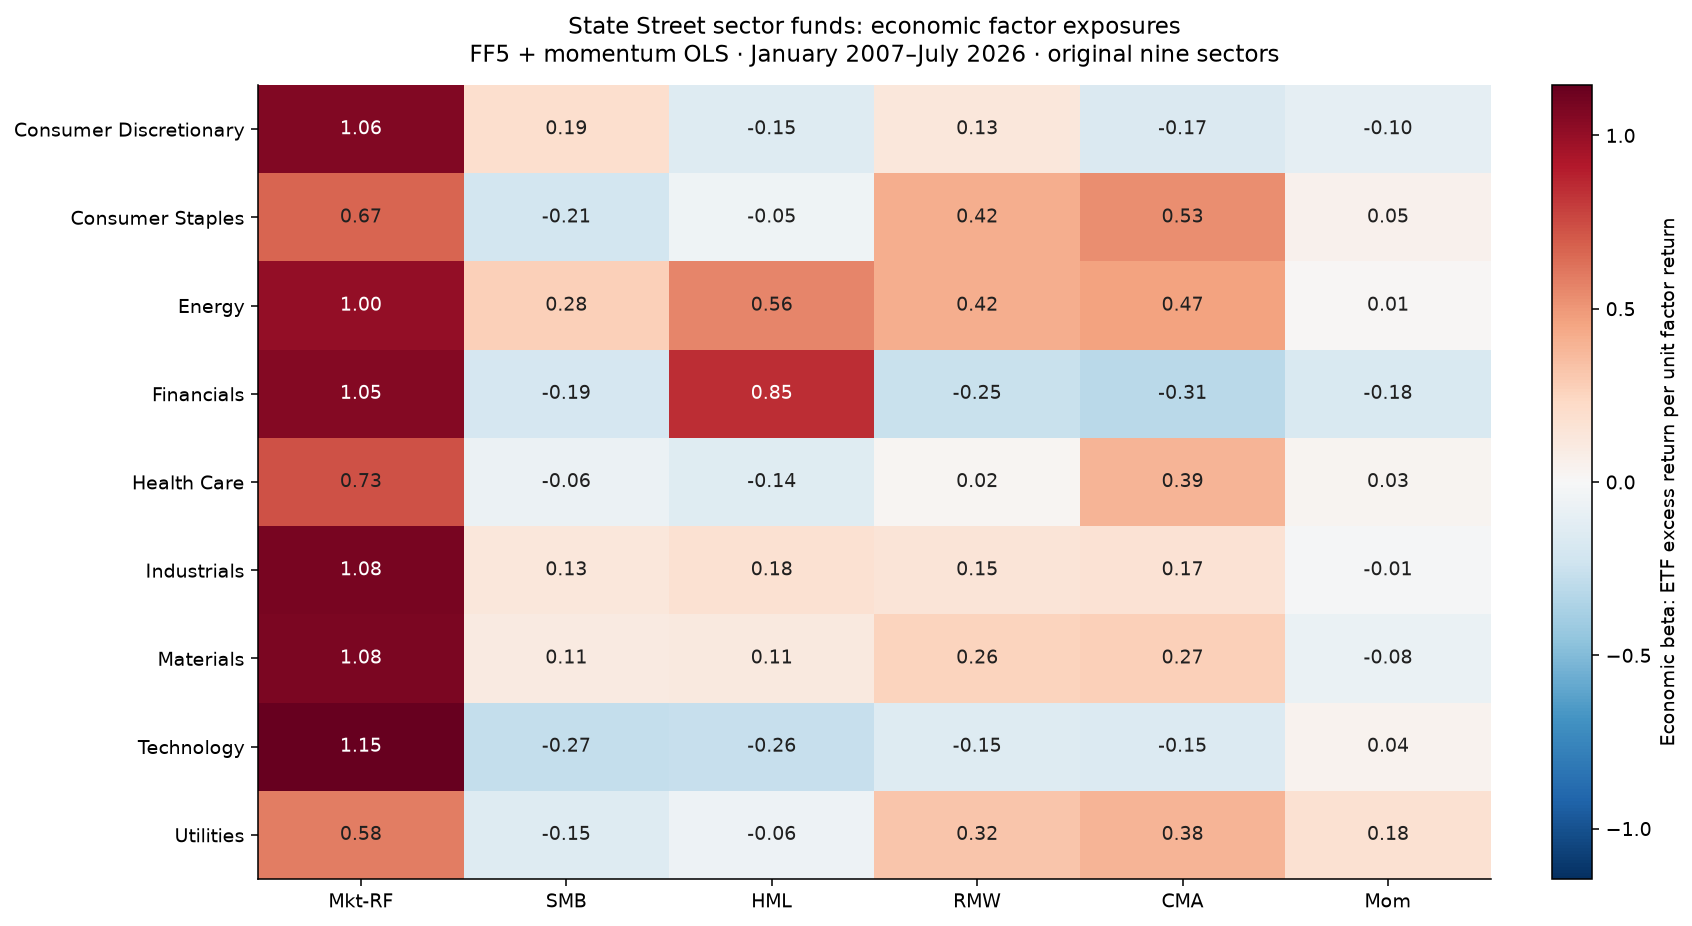

In [3]:
display(Image(filename=str(FIGURES / 'factor_map.png')))

## Reconcile the Technology sector in arithmetic return units
Technology is a fixed teaching example. The intercept, factor contributions and mean residual must reconcile to the mean ETF excess return. These annual arithmetic quantities do not compound to a wealth path. The sector fund's composition can change even when its current display name stays the same.

In [4]:
ticker = 'XLK'
fit = fit_factor_model(x.to_numpy(), y[ticker].to_numpy())
contributions = pd.Series(fit.beta * x.mean().to_numpy(), index=FACTORS)
contributions['Intercept'] = fit.intercept
residual = y[ticker].to_numpy() - fit.predict(x.to_numpy())
contributions['Mean residual'] = residual.mean()
assert np.isclose(contributions.sum(), y[ticker].mean(), atol=1e-12)
display((contributions * 1200).rename(f'{SECTORS[ticker]}: annual arithmetic contribution (%)').round(3).to_frame())

,Technology: annual arithmetic contribution (%)
Mkt-RF,11.760
SMB,0.111
HML,0.296
RMW,-0.478
CMA,-0.024
Mom,0.064
Intercept,3.870
Mean residual,0.000


## How much precision does the value loading have?
The HAC interval is model-conditional and pointwise. Correlated factors can make one coefficient imprecise even when the fitted total return is useful.

In [5]:
inference = hac_ols(x.to_numpy(), y[ticker].to_numpy(), lags=6)
j = FACTORS.index('HML') + 1
value_beta = inference.coefficients[j]
value_se = inference.standard_errors[j]
display(pd.DataFrame({'HML beta': [value_beta], 'Pointwise lower 95%': [value_beta - 1.96*value_se], 'Pointwise upper 95%': [value_beta + 1.96*value_se]}).round(3))

,HML beta,Pointwise lower 95%,Pointwise upper 95%
0,-0.262,-0.395,-0.128


## Include all eleven sectors without inventing their histories
Real Estate and Communication Services began trading later than the original nine funds. The common eleven-sector sample begins with July 2018 returns and ends in July 2026: 97 monthly observations. The next map estimates every sector on those same dates. It supplements the longer primary panel; comparisons between the maps combine a universe change with a sample-period change.

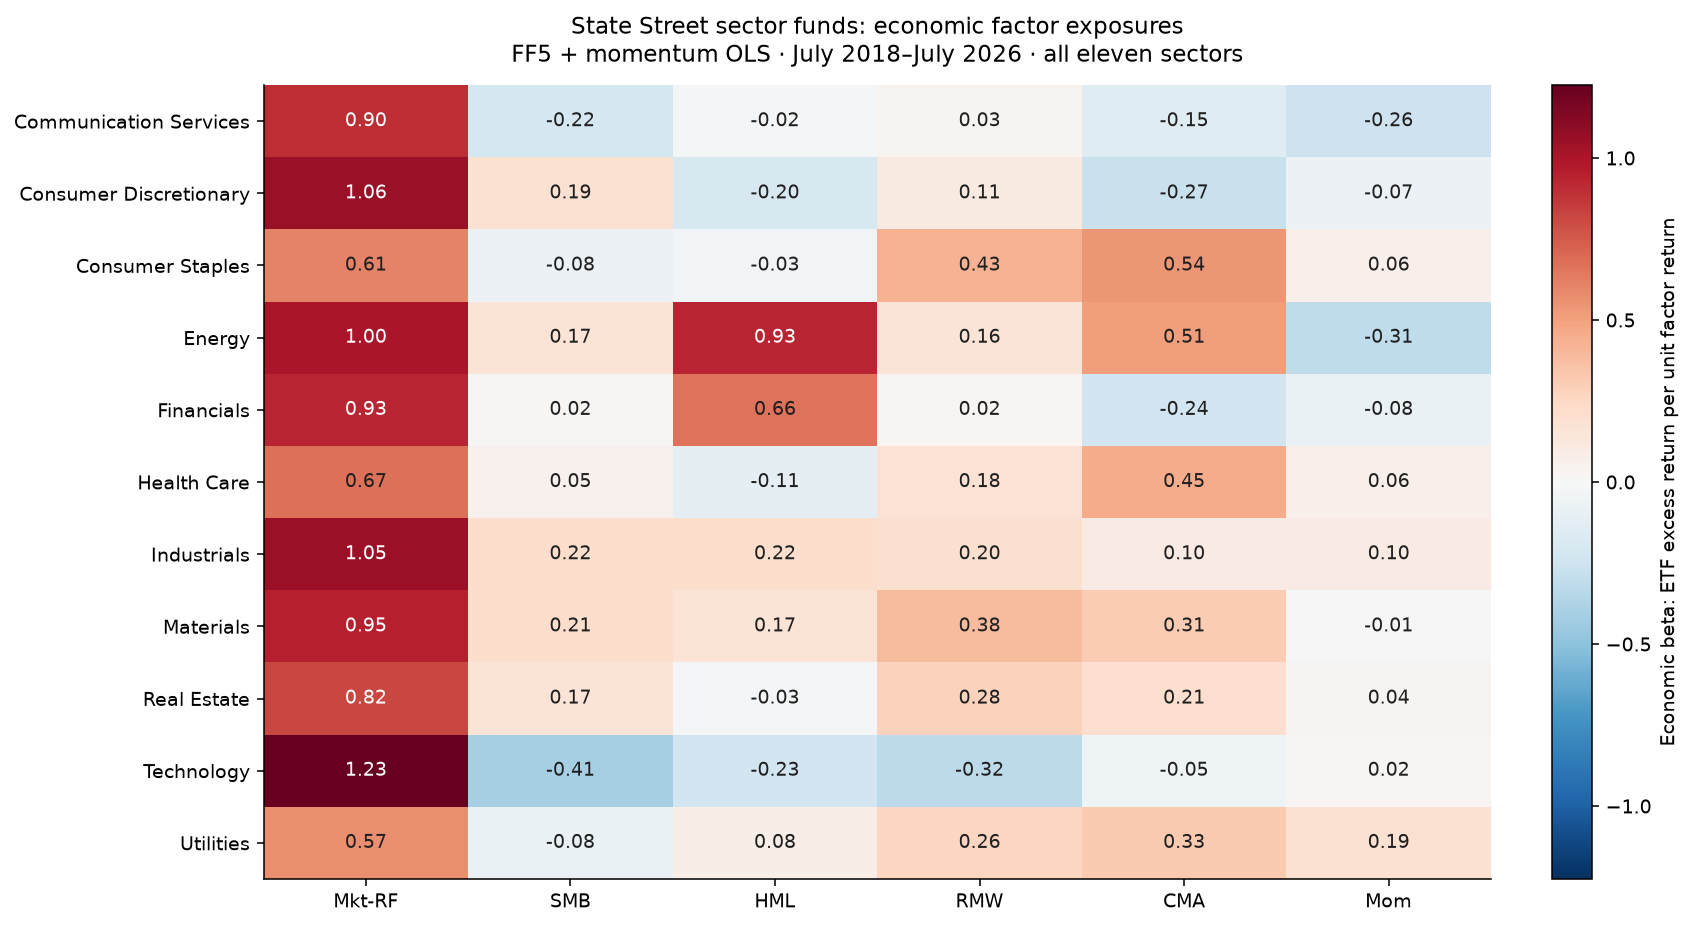

,Mkt-RF,SMB,HML,RMW,CMA,Mom
sector,,,,,,
Communication Services,0.902,-0.216,-0.015,0.034,-0.151,-0.256
Consumer Discretionary,1.058,0.187,-0.196,0.109,-0.273,-0.072
Consumer Staples,0.610,-0.075,-0.030,0.425,0.543,0.060
Energy,0.999,0.169,0.930,0.160,0.507,-0.310
Financials,0.934,0.016,0.662,0.025,-0.236,-0.080
Health Care,0.672,0.052,-0.110,0.179,0.454,0.064
Industrials,1.045,0.218,0.215,0.196,0.098,0.098
Materials,0.954,0.213,0.166,0.385,0.311,-0.006
Real Estate,0.817,0.167,-0.027,0.279,0.208,0.036


In [6]:
extended_x, extended_y, extended_audit = load_panel(extended=True)
assert len(extended_x) == 97 and extended_y.shape[1] == 11
display(Image(filename=str(FIGURES / 'extended_factor_map.png')))
extended_exposures = pd.read_csv(RESULTS / 'extended_exposures.csv').drop(columns='ticker').set_index('sector')
display(extended_exposures.round(3))

## Read the shorter reconstruction comparison in its own scope
A 60-month fit leaves only 37 evaluation months, July 2023–July 2026, in this eleven-sector panel. The table also includes the original nine sectors on those same recent dates. This recent-nine control separates the effect of adding Real Estate and Communication Services from the change in evaluation dates. Neither recent-panel estimate is directly comparable with the long-sample primary headline. These are equally weighted sector error summaries, not portfolio weights. A 120-month fitting window is infeasible, and no pre-inception ETF returns are supplied.

In [7]:
extended_head = json.loads((RESULTS / 'extended_headline.json').read_text())
recent_nine = extended_head['recent_nine']
assert extended_head['n'] == recent_nine['n'] == 37
display(pd.read_csv(RESULTS / 'extended_summary.csv').round(4))
display(pd.DataFrame([extended_head, recent_nine], index=['All eleven sectors, recent dates', 'Original nine sectors, same recent dates'])[['estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct', 'n']].rename(columns={'estimate': 'Ridge minus OLS MSE (pp²)', 'n': 'Evaluation months'}).round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept,universe
0,Market,37,11,3.8224,14.6105,0.0095,2.0000,All eleven sectors
1,FF5,37,11,3.6616,13.4074,0.0333,6.0000,All eleven sectors
2,OLS,37,11,3.6616,13.4070,0.0356,7.0000,All eleven sectors
3,Ridge 0.1,37,11,3.5727,12.7641,0.0268,6.1175,All eleven sectors
4,PCR 4,37,11,3.5848,12.8506,0.0311,5.0000,All eleven sectors
5,Market,37,9,3.9755,15.8047,0.0102,2.0000,Original nine on the same recent dates
6,FF5,37,9,3.7991,14.4330,0.0349,6.0000,Original nine on the same recent dates
7,OLS,37,9,3.7871,14.3420,0.0371,7.0000,Original nine on the same recent dates
8,Ridge 0.1,37,9,3.6845,13.5754,0.0278,6.1175,Original nine on the same recent dates
9,PCR 4,37,9,3.7140,13.7934,0.0319,5.0000,Original nine on the same recent dates


,Ridge minus OLS MSE (pp²),lower95,upper95,relative_mse_reduction_pct,Evaluation months
"All eleven sectors, recent dates",-0.6428,-1.0775,-0.1711,4.7949,37
"Original nine sectors, same recent dates",-0.7666,-1.3611,-0.1994,5.3453,37


## Interpretation
Energy exposure is not an oil futures position, utilities are not duration alone, and profitability beta is not an accounting screen applied to today's holdings. The fixed model and changing benchmark history limit those interpretations. [Data and fund identity](../../docs/01-data.md) discusses the 2016 Real Estate separation and 2018 Communication Services reclassification. Current sector names aid reading; they do not imply an unchanged historical mandate.